In [3]:
import cv2
import os

video_folder = "videos"
frames_folder = "frame1"

os.makedirs(frames_folder, exist_ok=True)

frame_global_count = 0
video_count = 0

for video_file in os.listdir(video_folder):

    if video_file.lower().endswith(".mp4"):

        video_count += 1
        video_path = os.path.join(video_folder, video_file)
        cap = cv2.VideoCapture(video_path)

        frame_count = 0
        video_name = os.path.splitext(video_file)[0]

        print("Processing:", video_file)

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % 10 == 0:

                filename = f"{video_name}_frame_{frame_global_count}.jpg"
                save_path = os.path.join(frames_folder, filename)

                cv2.imwrite(save_path, frame)
                frame_global_count += 1

            frame_count += 1

        cap.release()

print("\nFrame Extraction Completed.")
print("Total Videos Processed:", video_count)
print("Total Frames Extracted:", frame_global_count)

Processing: AlligatorCracking.mp4
Processing: EdgeCracking3.mp4
Processing: EdgeCracking4.mp4
Processing: EdgeCracking9.mp4
Processing: pedestrianCrossing.mp4
Processing: pedestrianCrossing2.mp4
Processing: RoadPotholes.mp4
Processing: RoadPotholes2.mp4
Processing: RoadPotholes3.mp4

Frame Extraction Completed.
Total Videos Processed: 9
Total Frames Extracted: 535



 NOISE CLASSIFICATION RESULTS 
                                Frame  Estimated Noise Variance  \
0       AlligatorCracking_frame_0.jpg                411.981598   
1      AlligatorCracking_frame_20.jpg                 80.105606   
2      AlligatorCracking_frame_35.jpg                 65.568123   
3       AlligatorCracking_frame_4.jpg                121.311234   
4      AlligatorCracking_frame_51.jpg                 66.147896   
5       AlligatorCracking_frame_9.jpg                 93.379646   
6          EdgeCracking3_frame_72.jpg                 62.881798   
7         EdgeCracking4_frame_123.jpg                 75.036499   
8         EdgeCracking4_frame_129.jpg                 84.499672   
9         EdgeCracking4_frame_130.jpg                 79.800003   
10        EdgeCracking4_frame_133.jpg                123.524391   
11        EdgeCracking4_frame_144.jpg                110.598404   
12        EdgeCracking4_frame_154.jpg                 59.082714   
13        EdgeCracking9_frame_

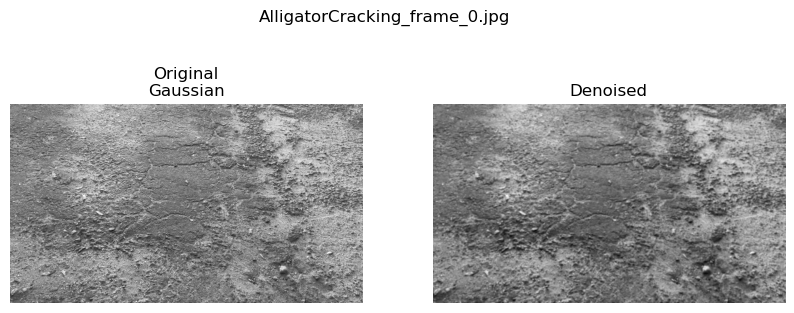

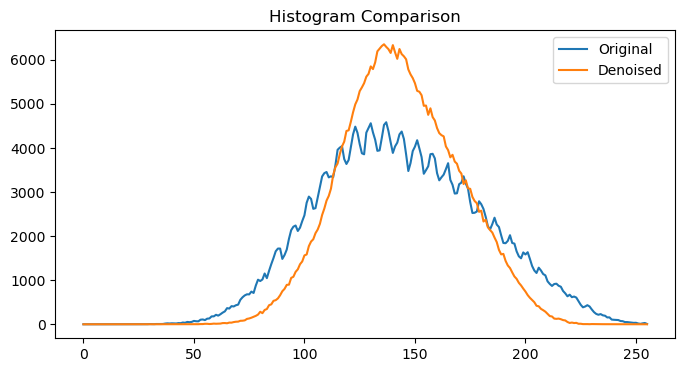

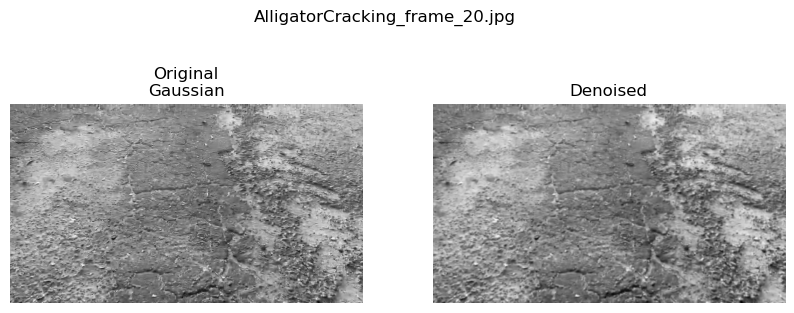

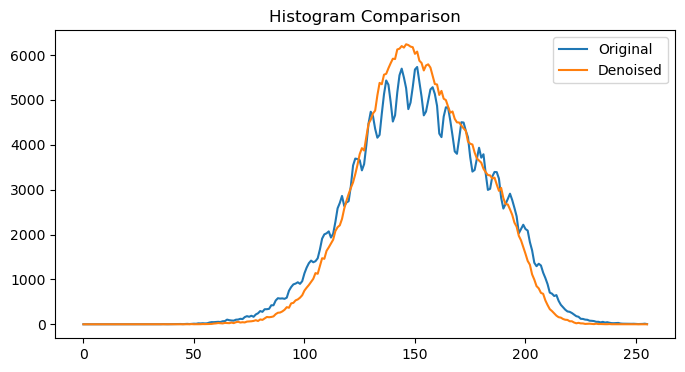

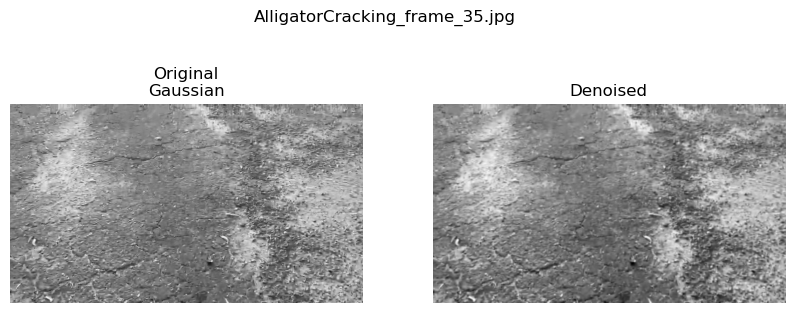

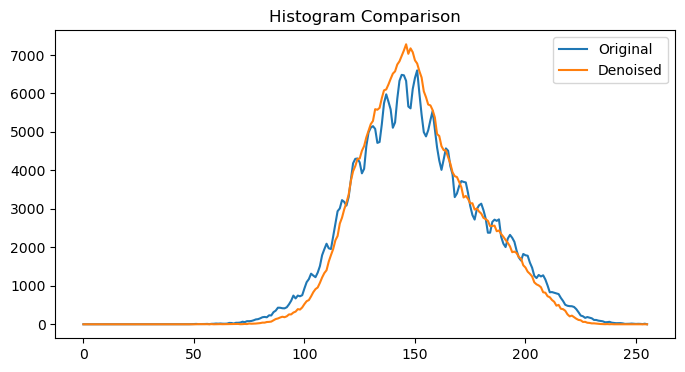

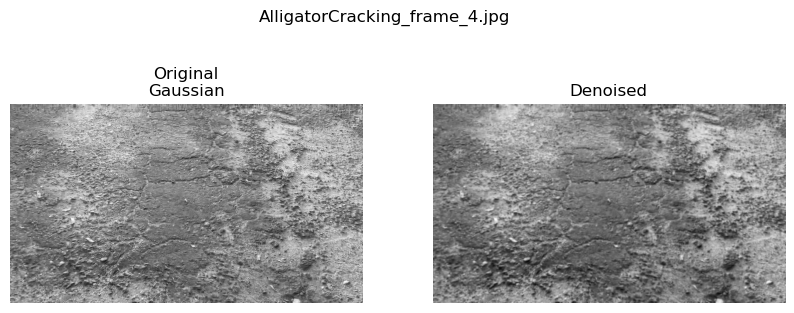

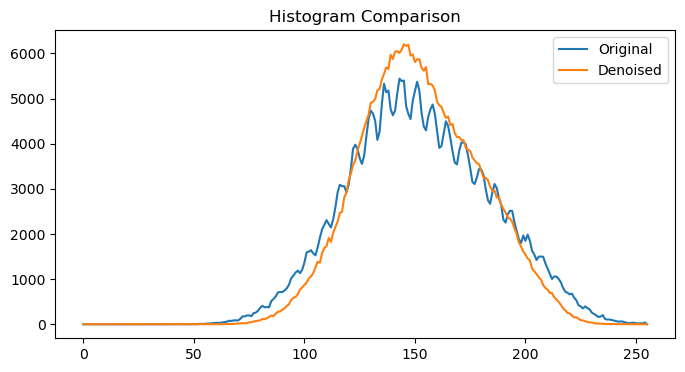

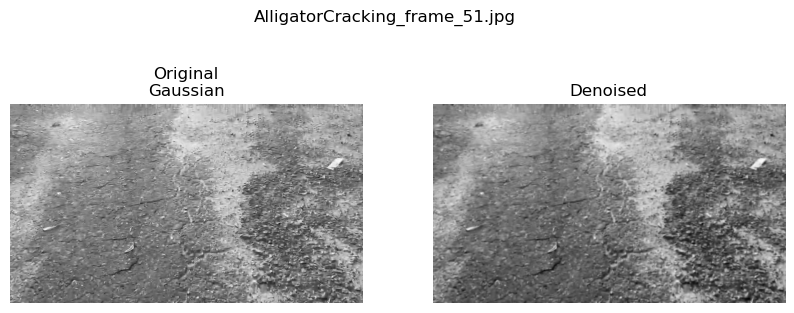

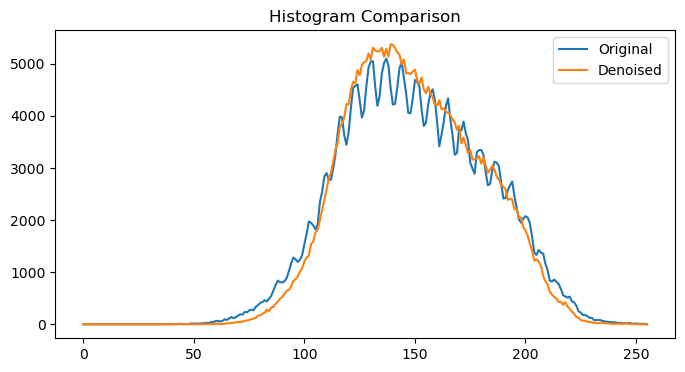

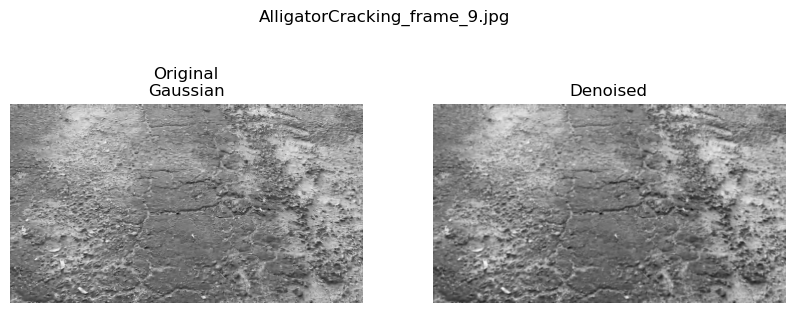

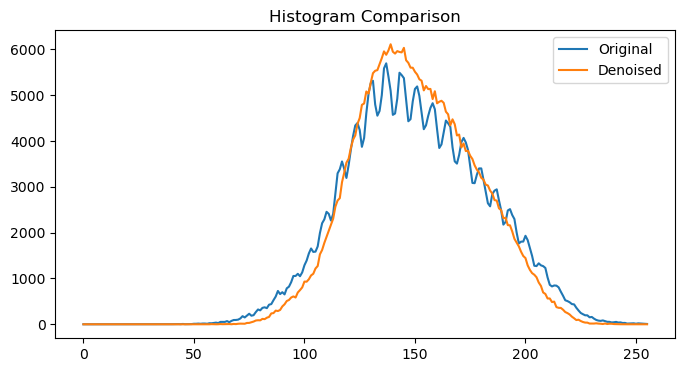

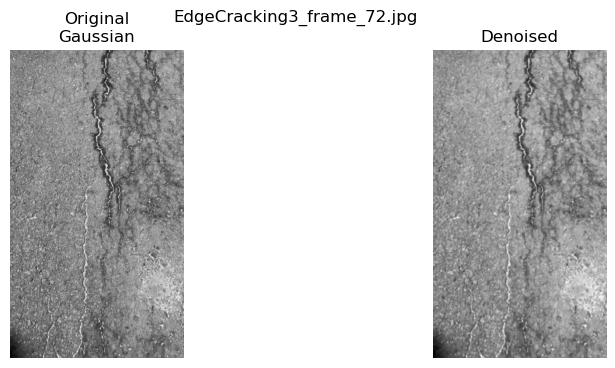

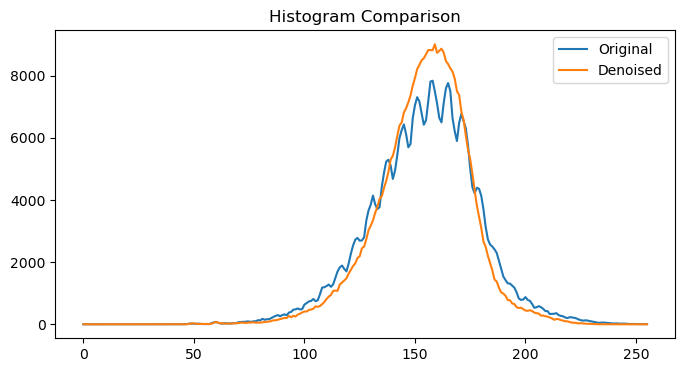

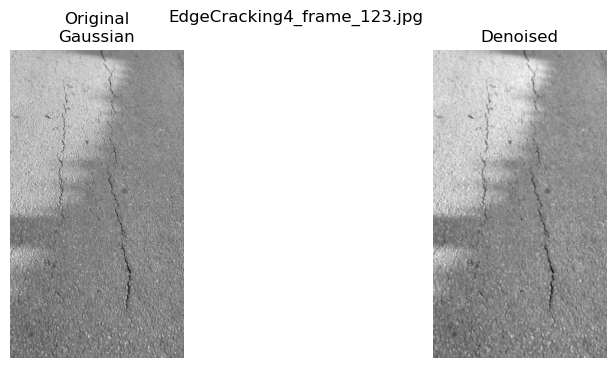

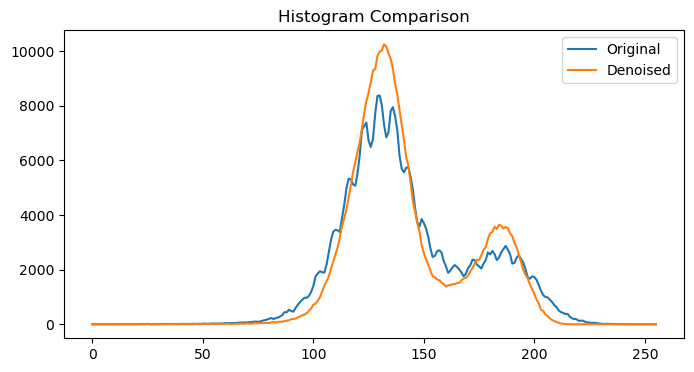

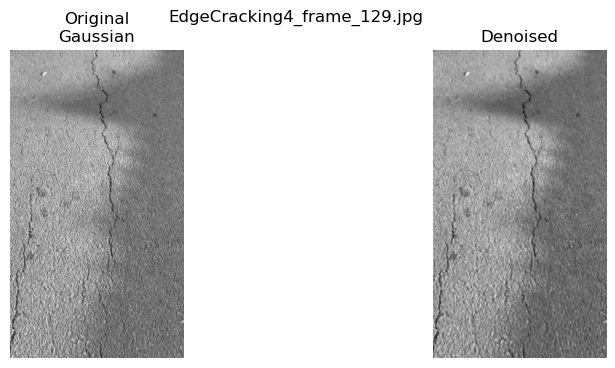

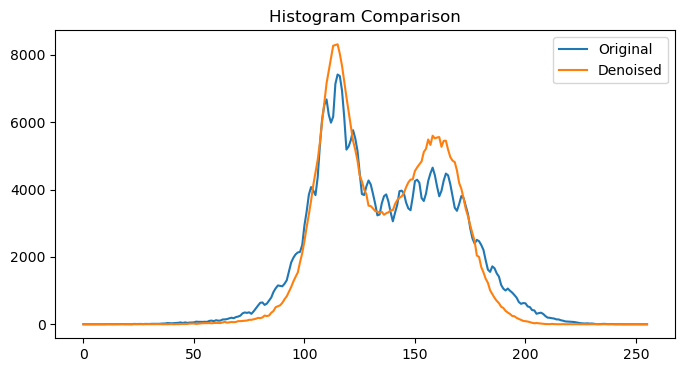

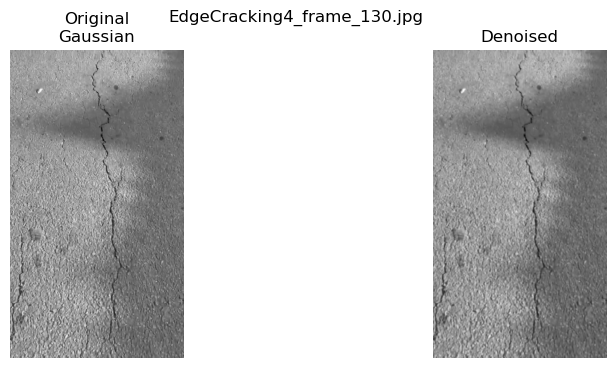

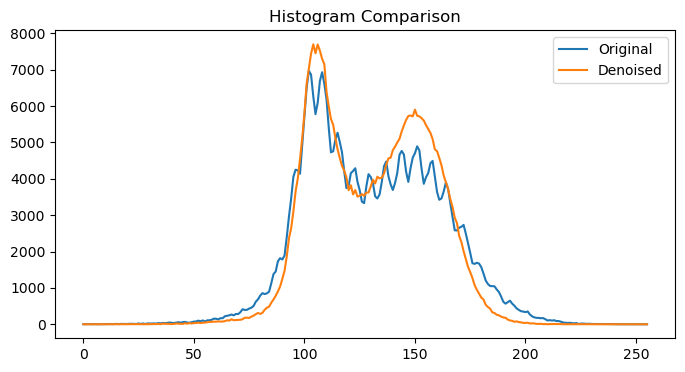

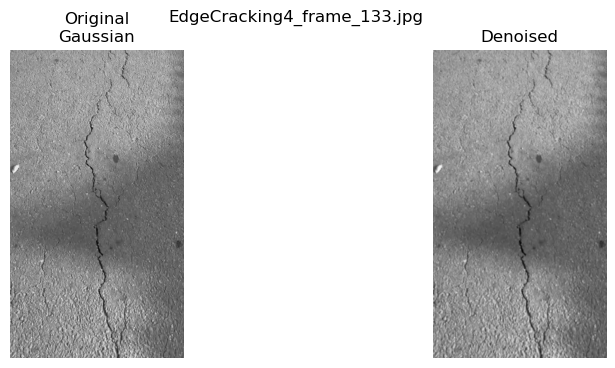

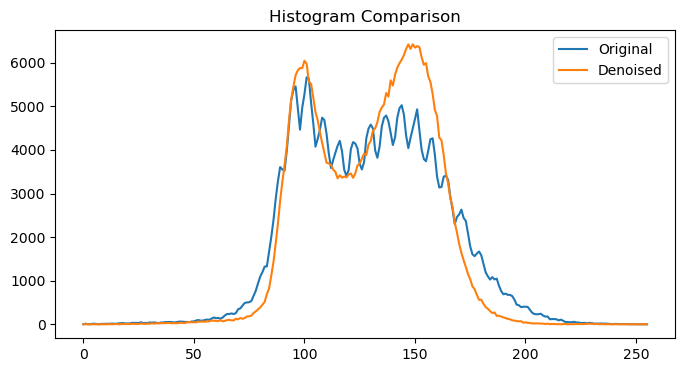

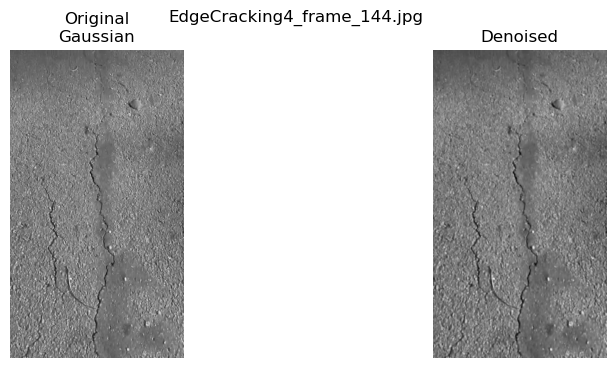

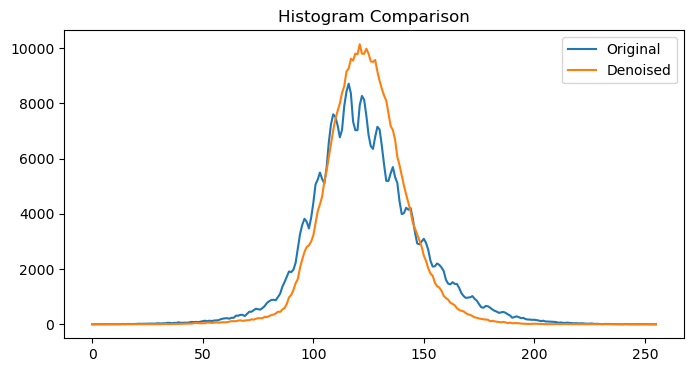

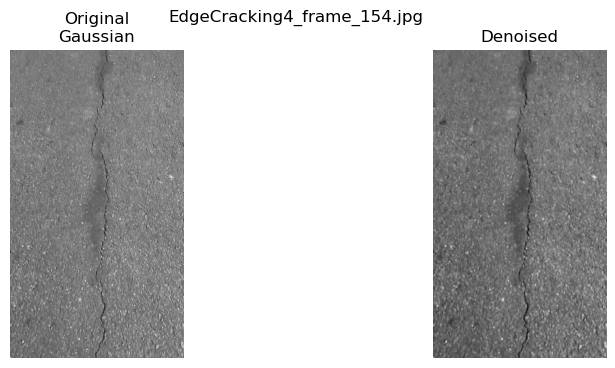

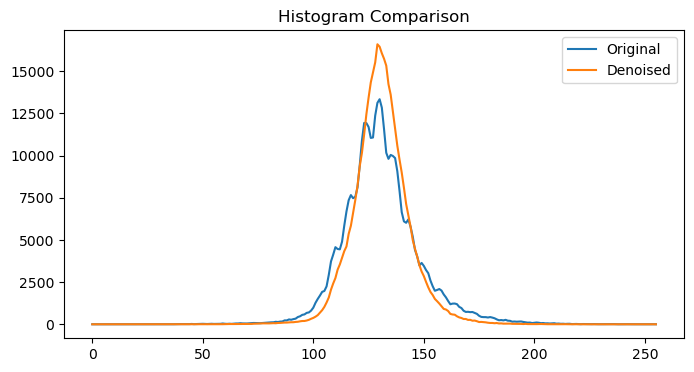

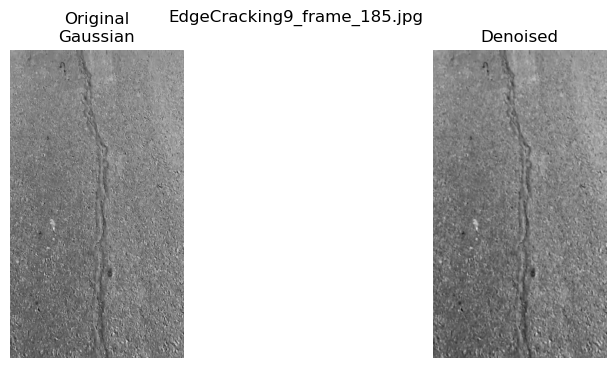

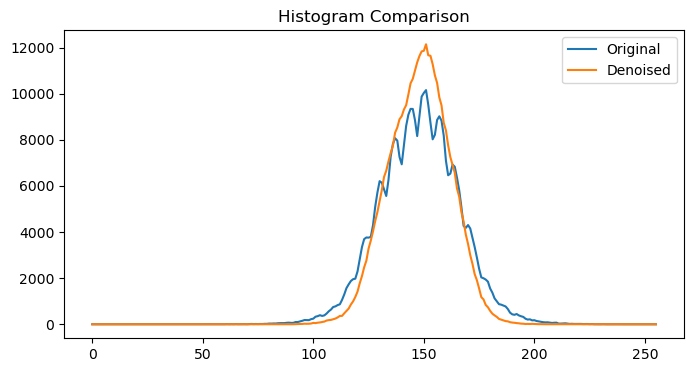

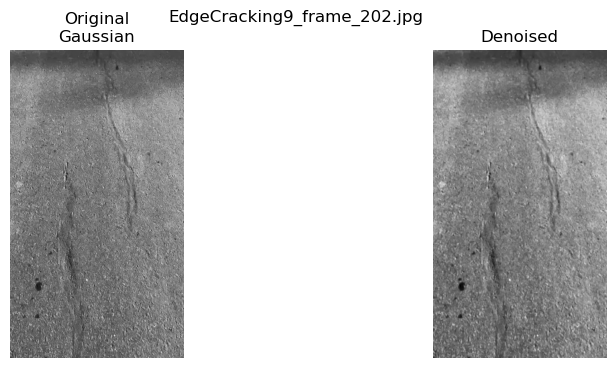

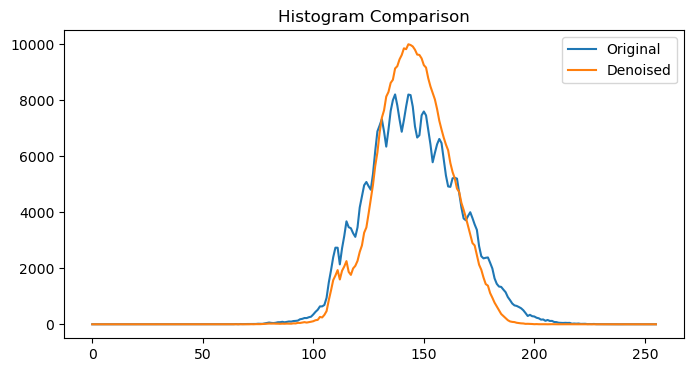

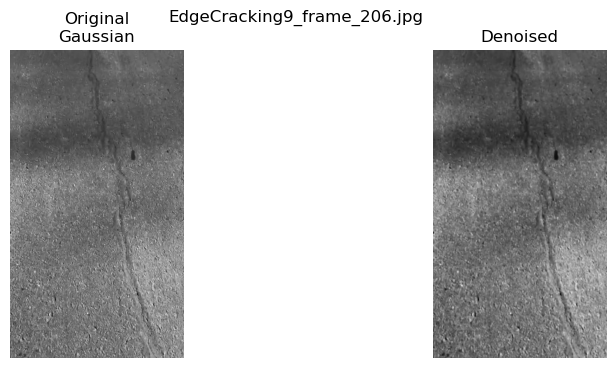

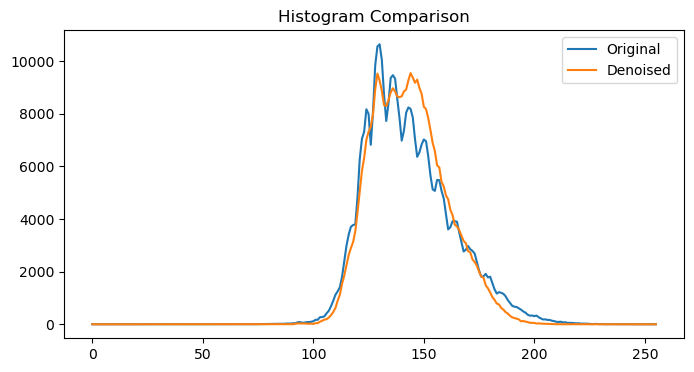

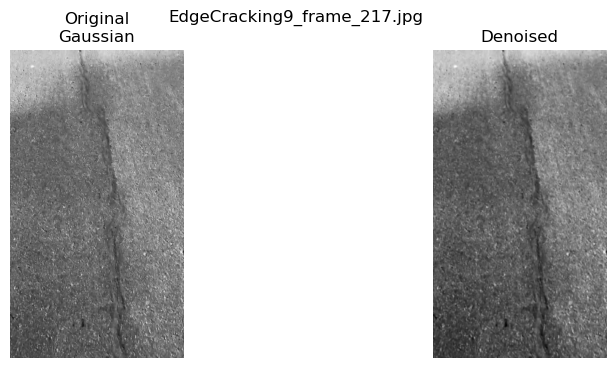

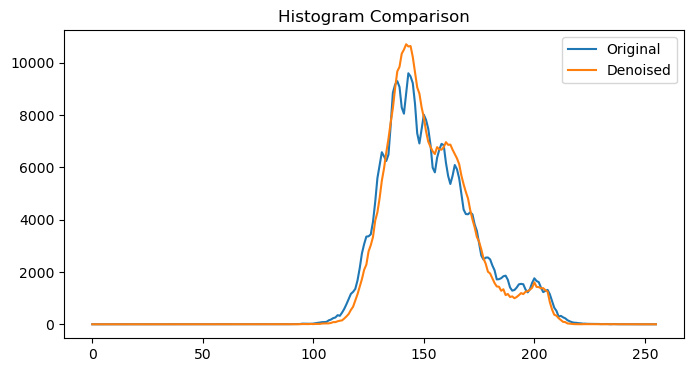

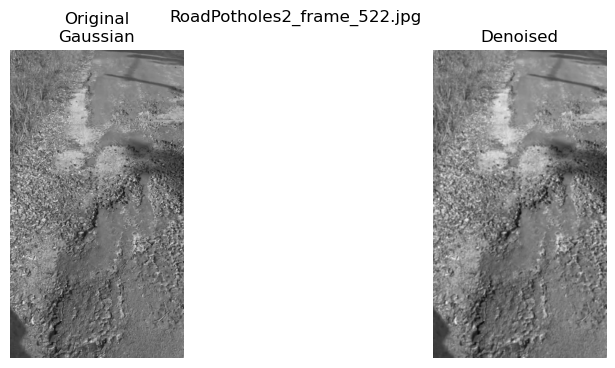

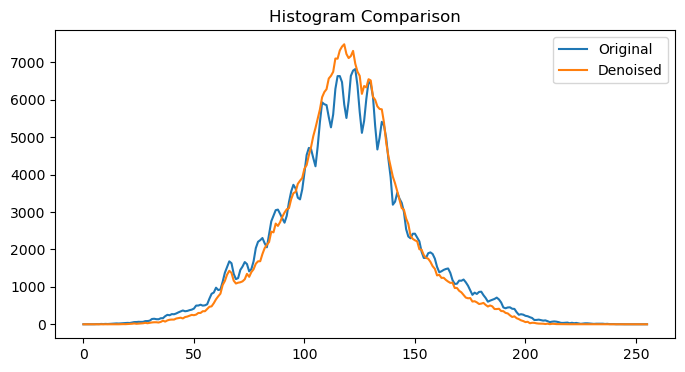

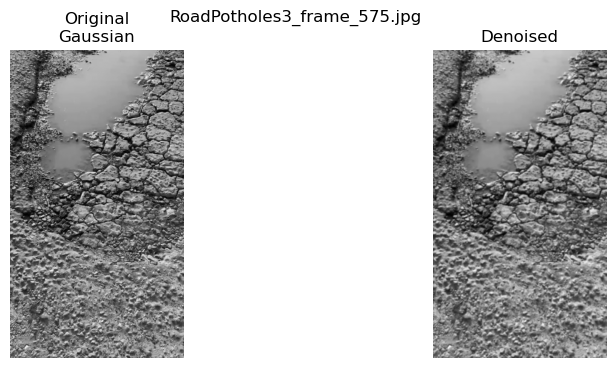

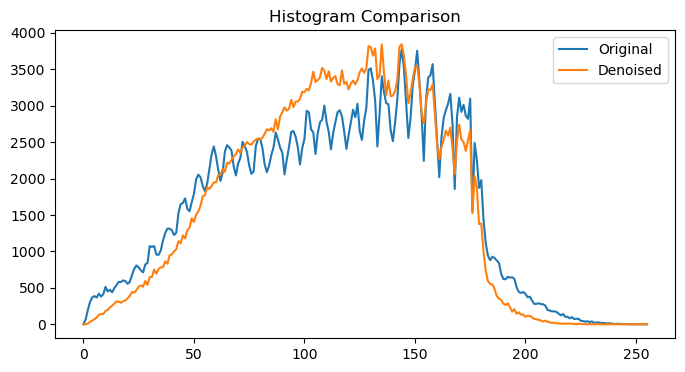

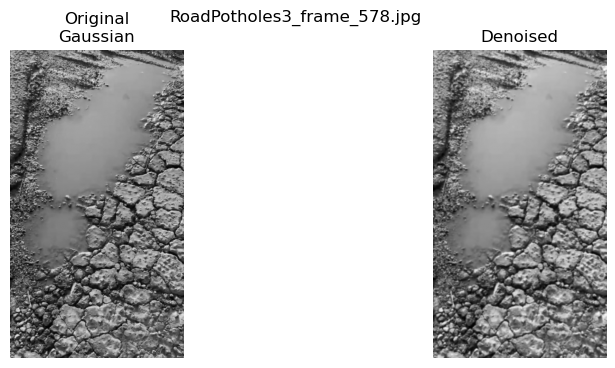

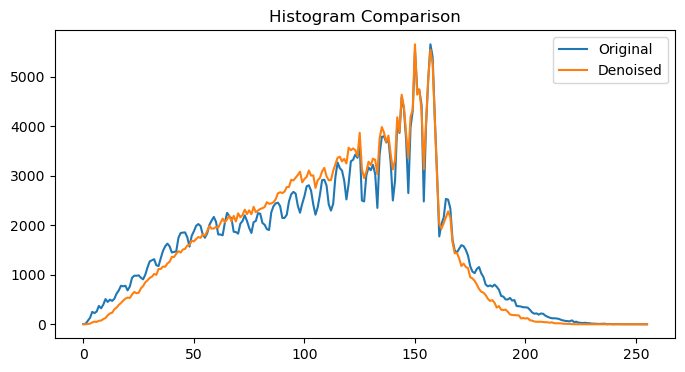

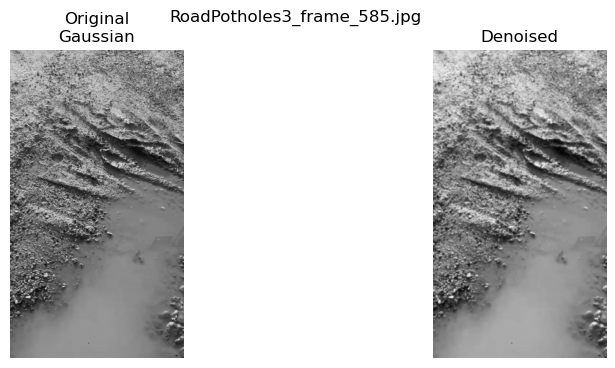

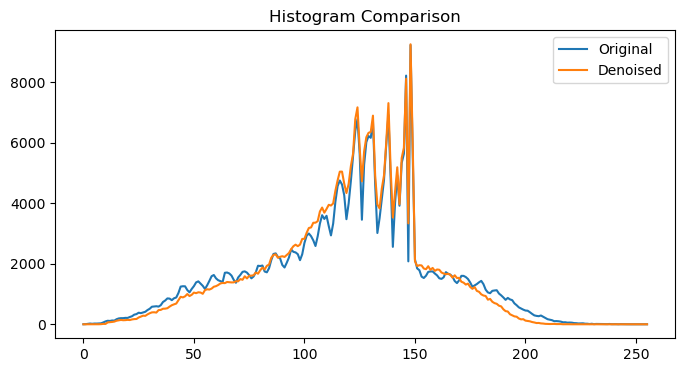

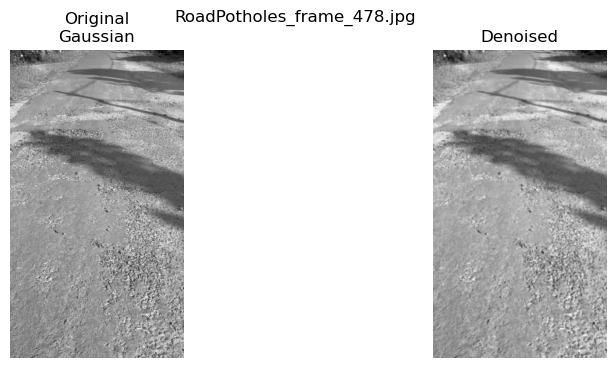

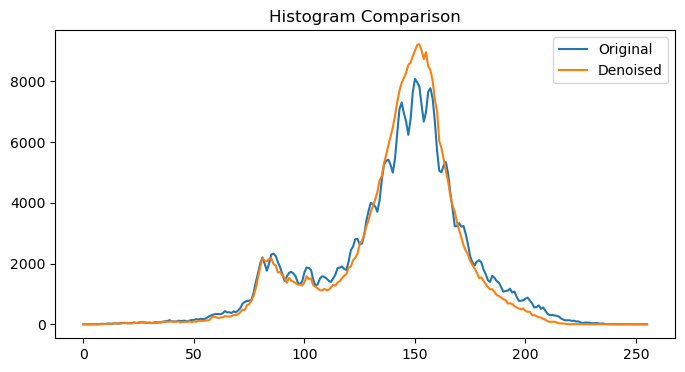

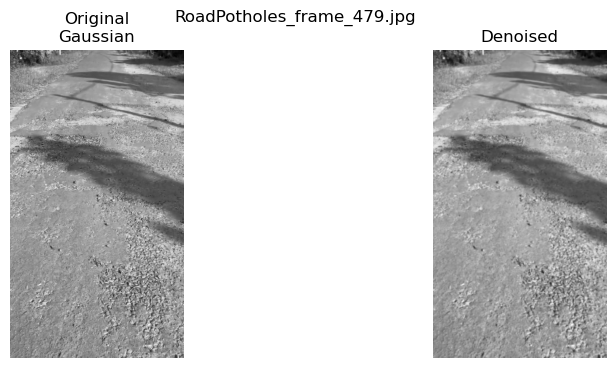

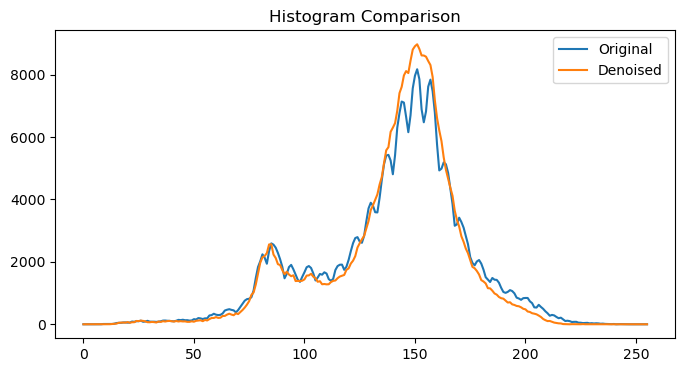

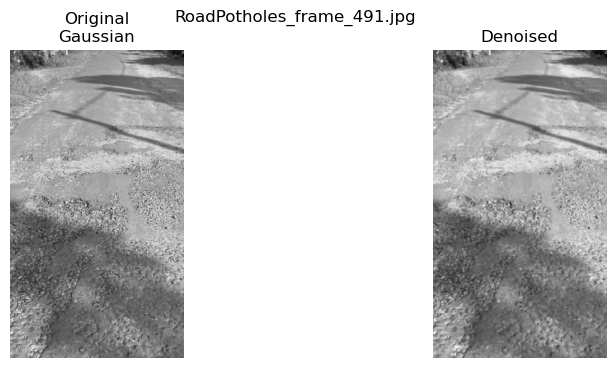

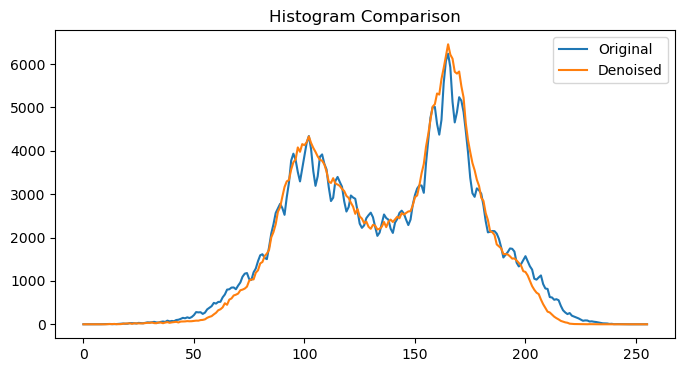

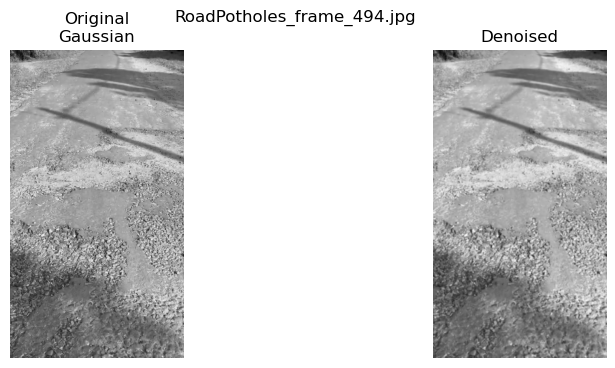

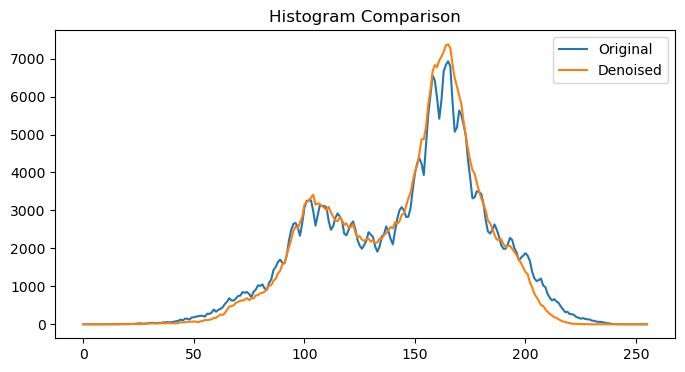

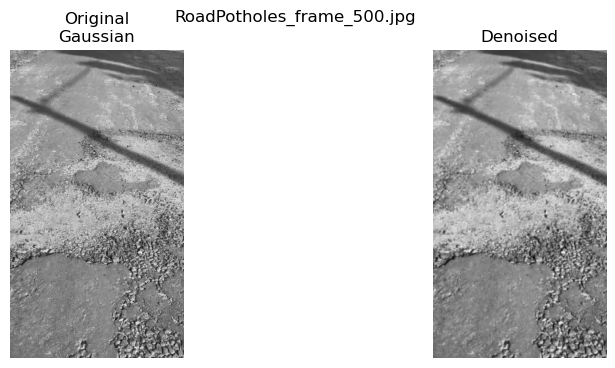

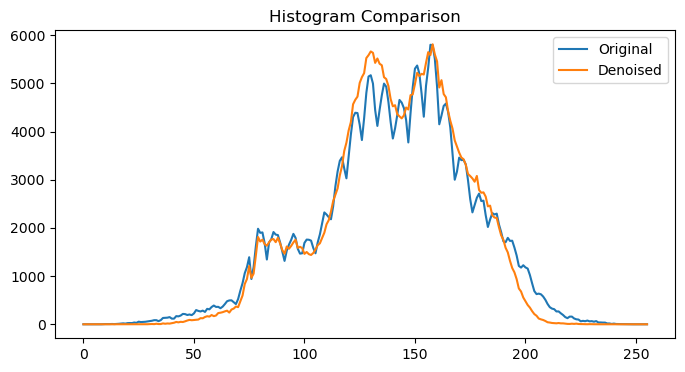

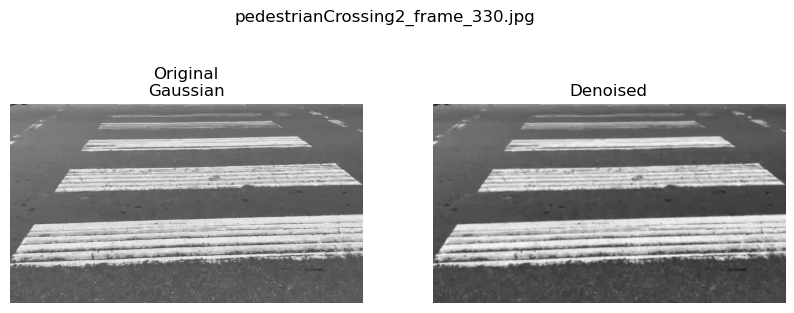

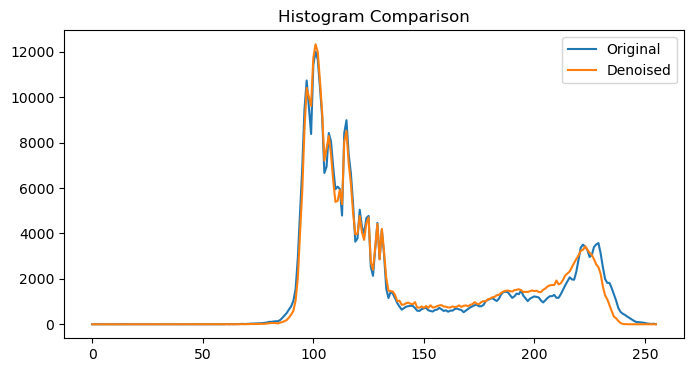

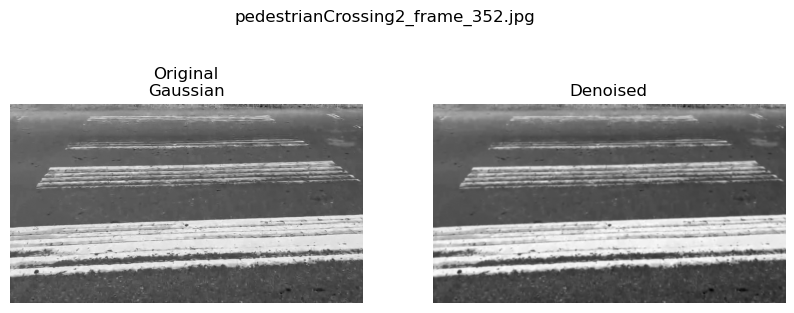

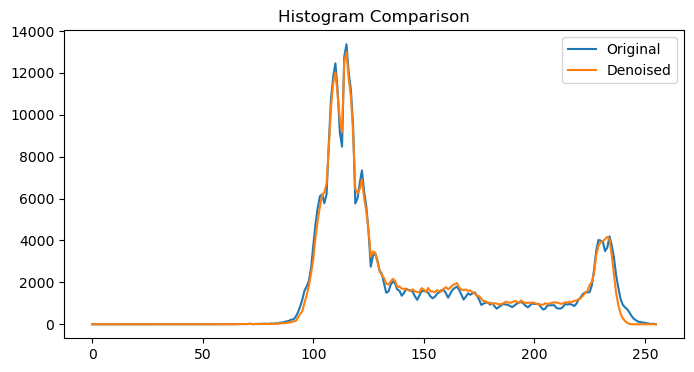

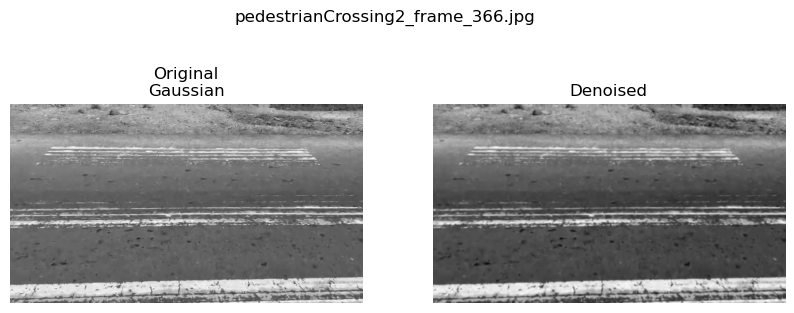

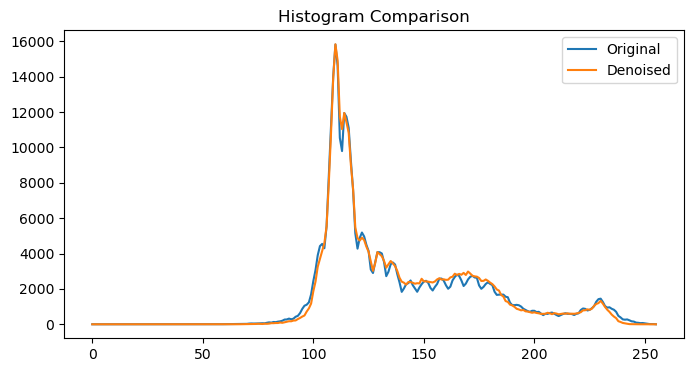

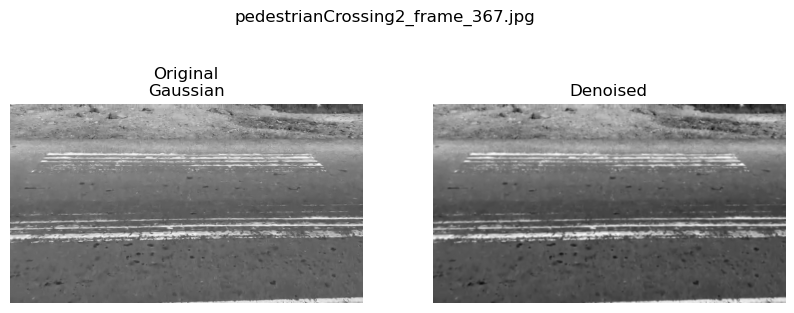

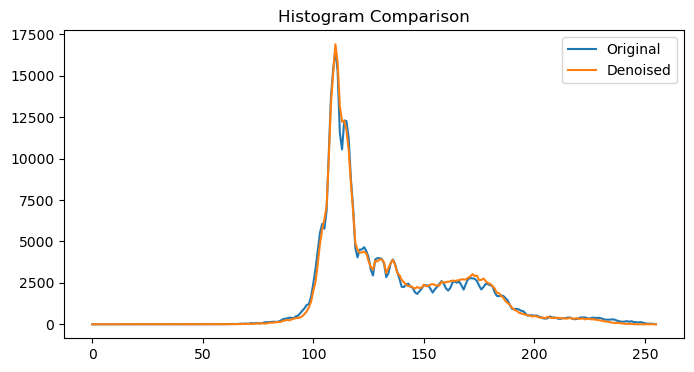

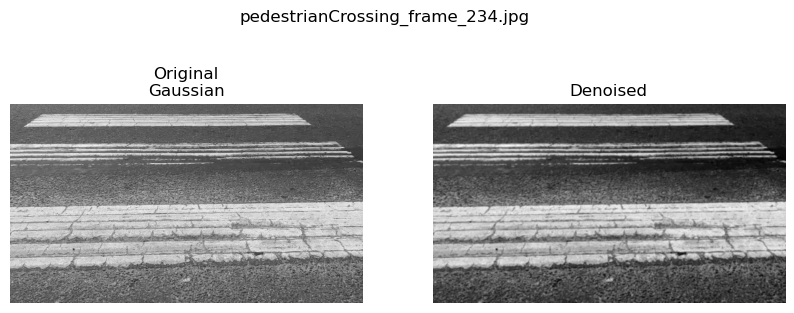

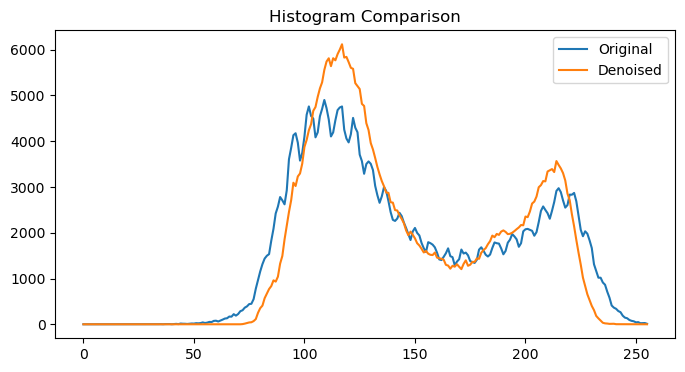

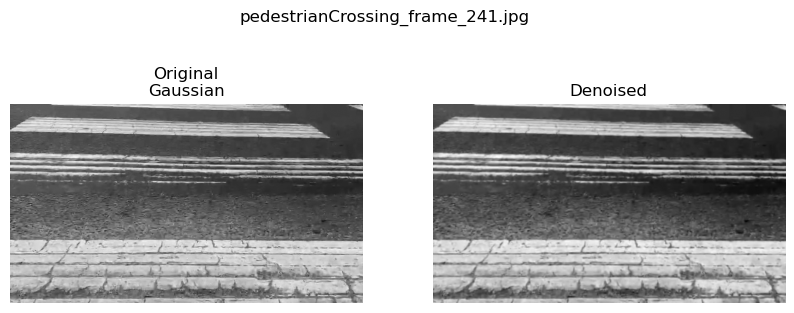

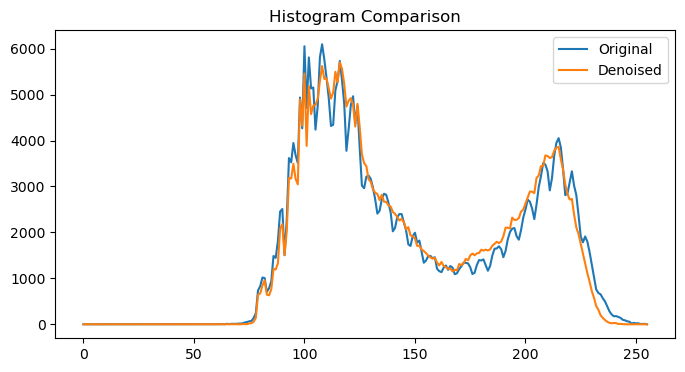

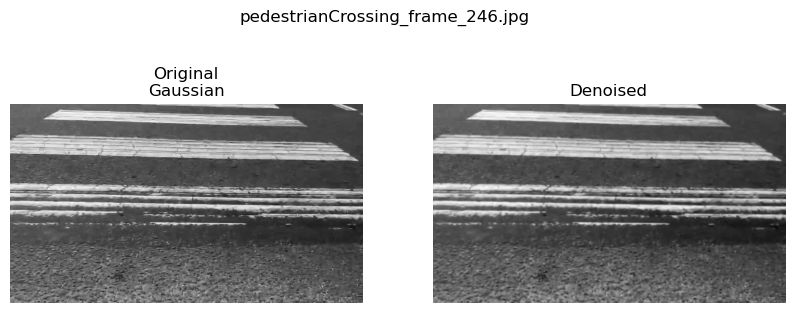

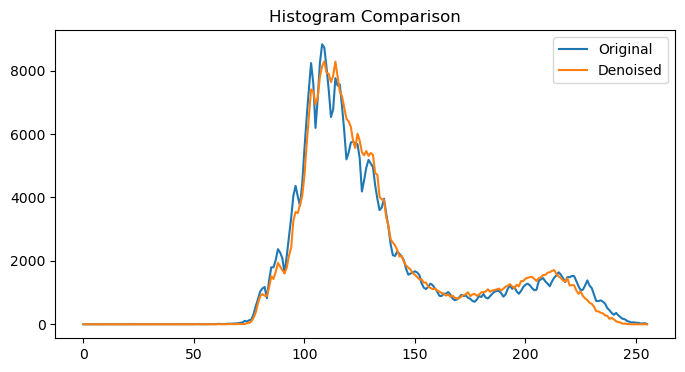


Noise Reduction Completed.
Frames Processed: 33

 NOISE REDUCTION EVALUATION 
                                Frame Noise Type  Noise Variance Before  \
0       AlligatorCracking_frame_0.jpg   Gaussian             411.981598   
1      AlligatorCracking_frame_20.jpg   Gaussian              80.105606   
2      AlligatorCracking_frame_35.jpg   Gaussian              65.568123   
3       AlligatorCracking_frame_4.jpg   Gaussian             121.311234   
4      AlligatorCracking_frame_51.jpg   Gaussian              66.147896   
5       AlligatorCracking_frame_9.jpg   Gaussian              93.379646   
6          EdgeCracking3_frame_72.jpg   Gaussian              62.881798   
7         EdgeCracking4_frame_123.jpg   Gaussian              75.036499   
8         EdgeCracking4_frame_129.jpg   Gaussian              84.499672   
9         EdgeCracking4_frame_130.jpg   Gaussian              79.800003   
10        EdgeCracking4_frame_133.jpg   Gaussian             123.524391   
11        EdgeCrackin

In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

frames_folder = "frames"
denoised_folder = "denoised_frames"

os.makedirs(denoised_folder, exist_ok=True)

def estimate_noise_variance(gray_image):
    blur = cv2.GaussianBlur(gray_image, (5, 5), 0)
    noise = gray_image.astype(np.float32) - blur.astype(np.float32)
    return np.var(noise)

def detect_salt_pepper(gray_image, threshold=0.02):
    total_pixels = gray_image.size
    extreme_pixels = np.sum((gray_image == 0) | (gray_image == 255))
    ratio = extreme_pixels / total_pixels
    return ratio > threshold

results = []
frame_files = sorted(os.listdir(frames_folder))

for file in frame_files:
    if file.lower().endswith((".jpg", ".png", ".jpeg", ".bmp", ".tif", ".tiff")):
        path = os.path.join(frames_folder, file)
        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        noise_var = estimate_noise_variance(gray)
        is_sp = detect_salt_pepper(gray)

        noise_type = "Salt & Pepper" if is_sp else "Gaussian"

        results.append([file, noise_var, noise_type])


df = pd.DataFrame(results, columns=["Frame", "Estimated Noise Variance", "Detected Noise Type"])

mean_noise = df["Estimated Noise Variance"].mean()
std_noise = df["Estimated Noise Variance"].std()

low_threshold = mean_noise - std_noise
high_threshold = mean_noise + std_noise

def classify_noise(val):
    if val < low_threshold:
        return "Low Noise"
    elif val > high_threshold:
        return "High Noise"
    else:
        return "Moderate Noise"

df["Noise Level"] = df["Estimated Noise Variance"].apply(classify_noise)

print("\n NOISE CLASSIFICATION RESULTS ")
print(df)
print("\nNoise Level Distribution:")
print(df["Noise Level"].value_counts())

frames_to_process = df[df["Noise Level"] != "Low Noise"]["Frame"].tolist()

evaluation = []

display_count = 0
max_display = 33

for frame_name in frames_to_process:

    path = os.path.join(frames_folder, frame_name)
    img = cv2.imread(path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    noise_type = df[df["Frame"] == frame_name]["Detected Noise Type"].values[0]

    if noise_type == "Salt & Pepper":
        denoised = cv2.medianBlur(gray, 5)
    else:
        denoised = cv2.GaussianBlur(gray, (5, 5), 0)

    cv2.imwrite(os.path.join(denoised_folder, frame_name), denoised)

    noise_before = estimate_noise_variance(gray)
    noise_after = estimate_noise_variance(denoised)

    evaluation.append([frame_name, noise_type, noise_before, noise_after])

    if display_count < max_display:

        # Display Before vs After
        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.imshow(gray, cmap="gray")
        plt.title(f"Original\n{noise_type}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(denoised, cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

        plt.suptitle(frame_name)
        plt.show()
        plt.close()

        plt.figure(figsize=(8,4))

        hist_orig = cv2.calcHist([gray],[0],None,[256],[0,256])
        hist_denoised = cv2.calcHist([denoised],[0],None,[256],[0,256])

        plt.plot(hist_orig, label="Original")
        plt.plot(hist_denoised, label="Denoised")
        plt.title("Histogram Comparison")
        plt.legend()
        plt.show()
        plt.close()

        display_count += 1

print("\nNoise Reduction Completed.")
print("Frames Processed:", len(frames_to_process))

eval_df = pd.DataFrame(
    evaluation,
    columns=["Frame","Noise Type","Noise Variance Before","Noise Variance After"]
)

print("\n NOISE REDUCTION EVALUATION ")
print(eval_df)

if not eval_df.empty:
    avg_before = eval_df["Noise Variance Before"].mean()
    avg_after = eval_df["Noise Variance After"].mean()

    print("\nAverage Noise Variance Before:", round(avg_before, 2))
    print("Average Noise Variance After :", round(avg_after, 2))
    print("Average Noise Reduction      :", round(avg_before - avg_after, 2))